Practice 2

2. Using logreg.predict_proba(X_test_scaled), find the threshold (steps of 0.05, 0.05 to 0.95) that maximizes recall on the malignant class (pos_label=0) while keeping its precision above 0.90. Report both metrics, and plot precision and recall against threshold, marking the one you chose. Then plot the confusion matrix at that threshold next to the Decision Tree's (tree, above): which one makes more false negatives on malignant?

Cell 1

In [3]:
# Import the libraries once at the beginning of the notebook.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    precision_score,recall_score,confusion_matrix,
    ConfusionMatrixDisplay)

Cell 2

In [4]:
# Load the Breast Cancer dataset and store it in a DataFrame.

data = load_breast_cancer(as_frame=True)

df = data.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Cell 3

In [5]:
# X contains the features, and y contains the target.

X = df.drop(columns="target")
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


Cell 4

In [6]:
# Split the data before fitting the model, and use stratify for classification.

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 455
Test size: 114


Cell 5

In [7]:
# Fit the scaler only on the training data.

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


Cell 6

In [8]:
# Fit Logistic Regression on the scaled training data.

logreg = LogisticRegression(max_iter=5000)

logreg.fit(X_train_scaled, y_train)

print(logreg)

LogisticRegression(max_iter=5000)


Cell 7

In [9]:
# predict_proba returns class probabilities instead of final labels.

y_proba = logreg.predict_proba(X_test_scaled)

print("Shape:", y_proba.shape)
print("First 5 probabilities:")
print(y_proba[:5])

Shape: (114, 2)
First 5 probabilities:
[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


Cell 8

In [10]:
# Column 1 is the probability of the benign class.

y_proba_benign = y_proba[:, 1]

print(y_proba_benign[:10].round(3))

[0.    1.    0.006 0.534 0.    0.992 1.    0.    0.    0.   ]


Cell 9

In [11]:
# Test thresholds from 0.05 to 0.95 with a step of 0.05.

thresholds = np.arange(0.05, 1.00, 0.05)

print(thresholds)

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


Cell 10

In [12]:
# For malignant evaluation, use pos_label=0 because malignant is encoded as 0.

precision_values = []
recall_values = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_benign >= threshold).astype(int)

    precision_malignant = precision_score(y_test,y_pred_threshold,pos_label=0,zero_division=0)

    recall_malignant = recall_score(y_test,y_pred_threshold,pos_label=0,zero_division=0)

    precision_values.append(precision_malignant)
    recall_values.append(recall_malignant)

Cell 11

In [13]:
# Choose the threshold with the highest recall among thresholds whose precision is above 0.90.

valid_indices = [i for i in range(len(thresholds))
    if precision_values[i] > 0.90]

best_index = max(valid_indices,key=lambda i: recall_values[i])

best_threshold = thresholds[best_index]
best_precision = precision_values[best_index]
best_recall = recall_values[best_index]

print("Best threshold:", round(best_threshold, 2))
print("Precision:", round(best_precision, 4))
print("Recall:", round(best_recall, 4))

Best threshold: 0.4
Precision: 0.9762
Recall: 0.9762


Cell 12

In [14]:
# Store threshold, precision, and recall together so the results can be compared.

results = pd.DataFrame({"Threshold": thresholds,"Precision": precision_values,"Recall": recall_values})
results.round(3)

,Threshold,Precision,Recall
0,0.05,1.000,0.857
1,0.10,1.000,0.881
2,0.15,1.000,0.905
3,0.20,1.000,0.952
4,0.25,1.000,0.952
5,0.30,1.000,0.952
6,0.35,1.000,0.952
7,0.40,0.976,0.976
8,0.45,0.976,0.976
9,0.50,0.976,0.976


Cell 13

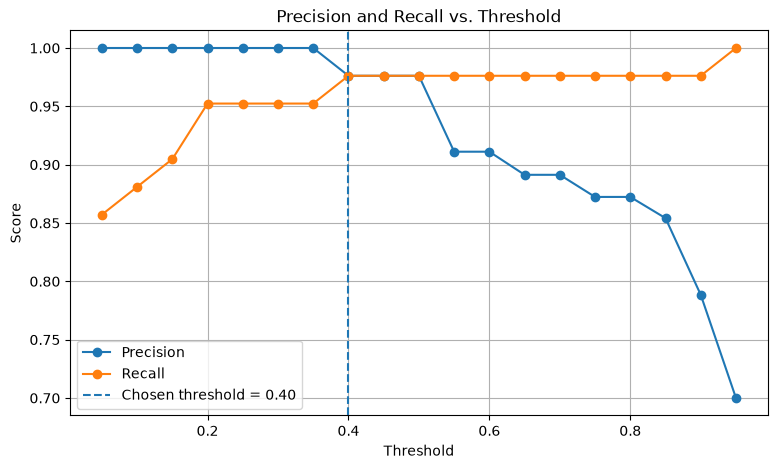

In [15]:
# Increasing the threshold changes the balance between precision and recall.

plt.figure(figsize=(9, 5))
plt.plot(thresholds,precision_values,marker="o",label="Precision")
plt.plot(thresholds,recall_values,marker="o",label="Recall")
plt.axvline(best_threshold,linestyle="--",label=f"Chosen threshold = {best_threshold:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Threshold")

plt.legend()
plt.grid()
plt.show()

Cell 14

In [16]:
# Convert probabilities into labels by comparing them with the chosen threshold.

y_pred_best = (y_proba_benign >= best_threshold).astype(int)

print("Chosen threshold:", best_threshold)
print("First 20 predictions:")
print(y_pred_best[:20])

Chosen threshold: 0.4
First 20 predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


Cell 15

In [17]:
# Use the same train/test split when comparing two models.

tree = DecisionTreeClassifier(max_depth=4,random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
cm_logreg = confusion_matrix(y_test,y_pred_best,labels=[0, 1])
cm_tree = confusion_matrix(y_test,y_pred_tree,labels=[0, 1])

print("Logistic Regression:")
print(cm_logreg)

print()

print("Decision Tree:")
print(cm_tree)

Logistic Regression:
[[41  1]
 [ 1 71]]

Decision Tree:
[[39  3]
 [ 4 68]]


Cell 16

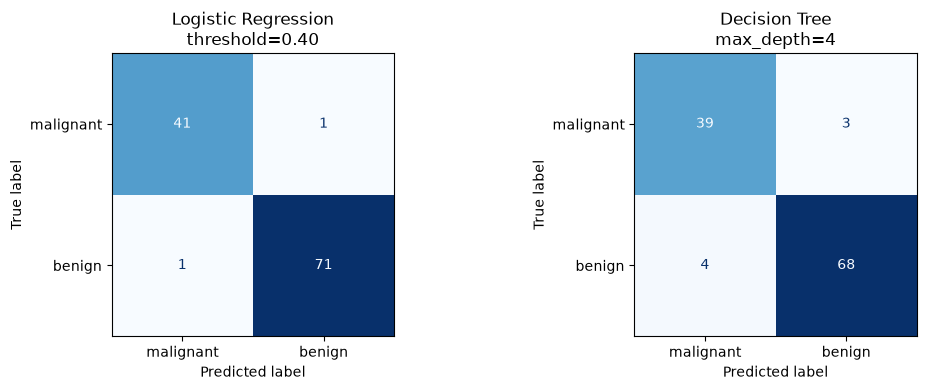

False Negatives for malignant
Logistic Regression: 1
Decision Tree: 3
Decision Tree makes more false negatives on malignant.


In [18]:
# For malignant as class 0, the false negatives are in row 0, column 1.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(confusion_matrix=cm_logreg,display_labels=["malignant", "benign"]).plot(
    ax=axes[0],cmap="Blues",colorbar=False)

axes[0].set_title(f"Logistic Regression\nthreshold={best_threshold:.2f}")

ConfusionMatrixDisplay(confusion_matrix=cm_tree,display_labels=["malignant", "benign"]
).plot(ax=axes[1],cmap="Blues",colorbar=False)

axes[1].set_title("Decision Tree\nmax_depth=4")

plt.tight_layout()
plt.show()


fn_logreg = cm_logreg[0, 1]
fn_tree = cm_tree[0, 1]

print("False Negatives for malignant")
print("Logistic Regression:", fn_logreg)
print("Decision Tree:", fn_tree)

if fn_logreg > fn_tree:
    print("Logistic Regression makes more false negatives on malignant.")
elif fn_tree > fn_logreg:
    print("Decision Tree makes more false negatives on malignant.")
else:
    print("Both models make the same number of false negatives on malignant.")